In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"..\..\PS_20174392719_1491204439457_log.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


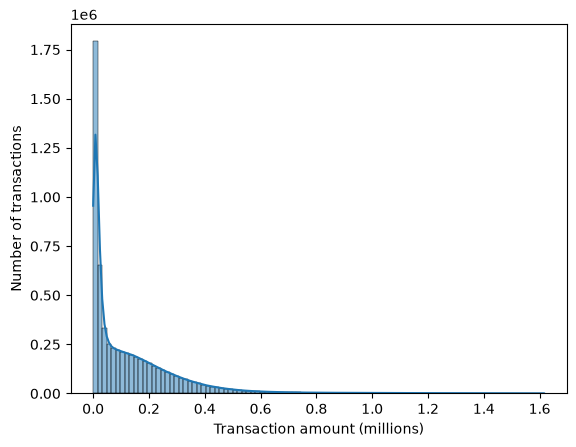

In [4]:
limit = df["amount"].quantile(0.99)
df_plot = df.loc[df["amount"] <= limit].copy()
df_plot["amount_millions"] = df_plot["amount"] / 1000000

sns.histplot(
    data=df_plot,
    x="amount_millions",
    bins=100,
    kde=True
)
plt.xlabel("Transaction amount (millions)")
plt.ylabel("Number of transactions")
plt.show()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.select_dtypes(np.number).isna().sum()

step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.shape

(6362620, 11)

In [9]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [10]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df["isFlaggedFraud"].info()

<class 'pandas.Series'>
RangeIndex: 6362620 entries, 0 to 6362619
Series name: isFlaggedFraud
Non-Null Count    Dtype
--------------    -----
6362620 non-null  int64
dtypes: int64(1)
memory usage: 48.5 MB


In [12]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
df["type"][df["isFraud"]==1].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

In [14]:
df["isFraud"][df["isFlaggedFraud"]==1].value_counts()

isFraud
1    16
Name: count, dtype: int64

In [15]:
df=df.drop('isFlaggedFraud',axis=1)

In [16]:
df = df[df['type'].isin(['TRANSFER', 'PAYMENT'])]

In [17]:
df[df.duplicated()].sum()

step                0
type                 
amount            0.0
nameOrig             
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest             
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud             0
dtype: object

In [18]:
df.loc[df["isFraud"] == 1, ["nameDest", "nameOrig"]]

,nameDest,nameOrig
2,C553264065,C1305486145
251,C972765878,C1420196421
680,C1848415041,C137533655
969,C431687661,C1334405552
1115,C1136419747,C1364127192
...,...,...
6362610,C1812552860,C778071008
6362612,C1470998563,C1531301470
6362614,C1850423904,C2013999242
6362616,C1881841831,C1529008245


In [19]:
fraud_account_lengths = df.loc[df["isFraud"] == 1, ["nameDest", "nameOrig"]].copy()
fraud_account_lengths["nameDest_length"] = fraud_account_lengths["nameDest"].str.len()
fraud_account_lengths["nameOrig_length"] = fraud_account_lengths["nameOrig"].str.len()

fraud_account_lengths.sample(15)

,nameDest,nameOrig,nameDest_length,nameOrig_length
1030621,C154560289,C32677445,10,9
4424098,C1860612852,C516411527,11,10
4388746,C96624580,C954160536,9,10
4782360,C539311335,C464058059,10,10
5628265,C96260697,C461302689,9,10
6117187,C942070496,C1635920550,10,11
6061807,C1852963634,C2091895045,11,11
6168737,C1685479165,C959095165,11,10
5871055,C1759607478,C1682150994,11,11
576324,C136618845,C842027258,10,10


In [20]:
df[df["isFraud"]==1].head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.0,1
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.0,1
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.0,1
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.0,1
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.0,1
1869,1,TRANSFER,25071.46,C669700766,25071.46,0.0,C1384210339,0.0,0.0,1
2301,1,TRANSFER,235238.66,C1872047468,235238.66,0.0,C116289363,0.0,0.0,1
3059,2,TRANSFER,1096187.24,C1093223281,1096187.24,0.0,C2063275841,0.0,0.0,1
3162,2,TRANSFER,963532.14,C1440057381,963532.14,0.0,C268086000,0.0,0.0,1
3271,2,TRANSFER,14949.84,C140702728,14949.84,0.0,C634210724,0.0,0.0,1


In [21]:
df['hour'] = df['step'] % 24  # Extract hour from step (since 1 step = 1 hour)
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)  # Flag night transactions

In [22]:
df['sender_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

In [23]:
# Unexpected Zero Balances
#In fraudulent transactions, balances might remain unchanged.
#orig_balance_zero: Indicates whether the sender had a zero balance before the transaction.
#dest_balance_zero: Indicates whether the receiver had a zero balance before the transaction. #### Fraudsters may use new accounts with zero balance to receive money.

In [24]:
df['orig_balance_zero'] = (df['oldbalanceOrg'] == 0).astype('Int64')
df['dest_balance_zero'] = (df['oldbalanceDest'] == 0).astype("int64")

In [25]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,9839.64,0.0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,1864.28,0.0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,181.00,0.0,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,11668.14,0.0,0,1
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,1,1,7817.71,0.0,0,1


In [26]:
df.columns = df.columns.str.strip()

In [27]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'hour',
       'is_night', 'sender_balance_change', 'receiver_balance_change',
       'orig_balance_zero', 'dest_balance_zero'],
      dtype='str')

In [28]:
# Catergical Encoding
col = "type"
type_ohe = pd.get_dummies(df[col],prefix=col).astype("int64")
df = pd.concat([df,type_ohe],axis=1).reset_index(drop=True)
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_PAYMENT,type_TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.0,0,1,1,9839.64,0.0,0,1,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.0,0,1,1,1864.28,0.0,0,1,1,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.0,1,1,1,181.00,0.0,0,1,0,1
3,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.0,0,1,1,11668.14,0.0,0,1,1,0
4,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.0,0,1,1,7817.71,0.0,0,1,1,0
5,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.0,0,1,1,7107.77,0.0,0,1,1,0
6,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.0,0,1,1,7861.64,0.0,0,1,1,0
7,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.0,0,1,1,2671.00,0.0,0,1,1,0
8,1,PAYMENT,3099.97,C249177573,20771.00,17671.03,M2096539129,0.0,0.0,0,1,1,3099.97,0.0,0,1,1,0
9,1,PAYMENT,2560.74,C1648232591,5070.00,2509.26,M972865270,0.0,0.0,0,1,1,2560.74,0.0,0,1,1,0


In [29]:
#Dropping Irrelevant Columns :
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [30]:
df.shape

(2684404, 16)

<Axes: >

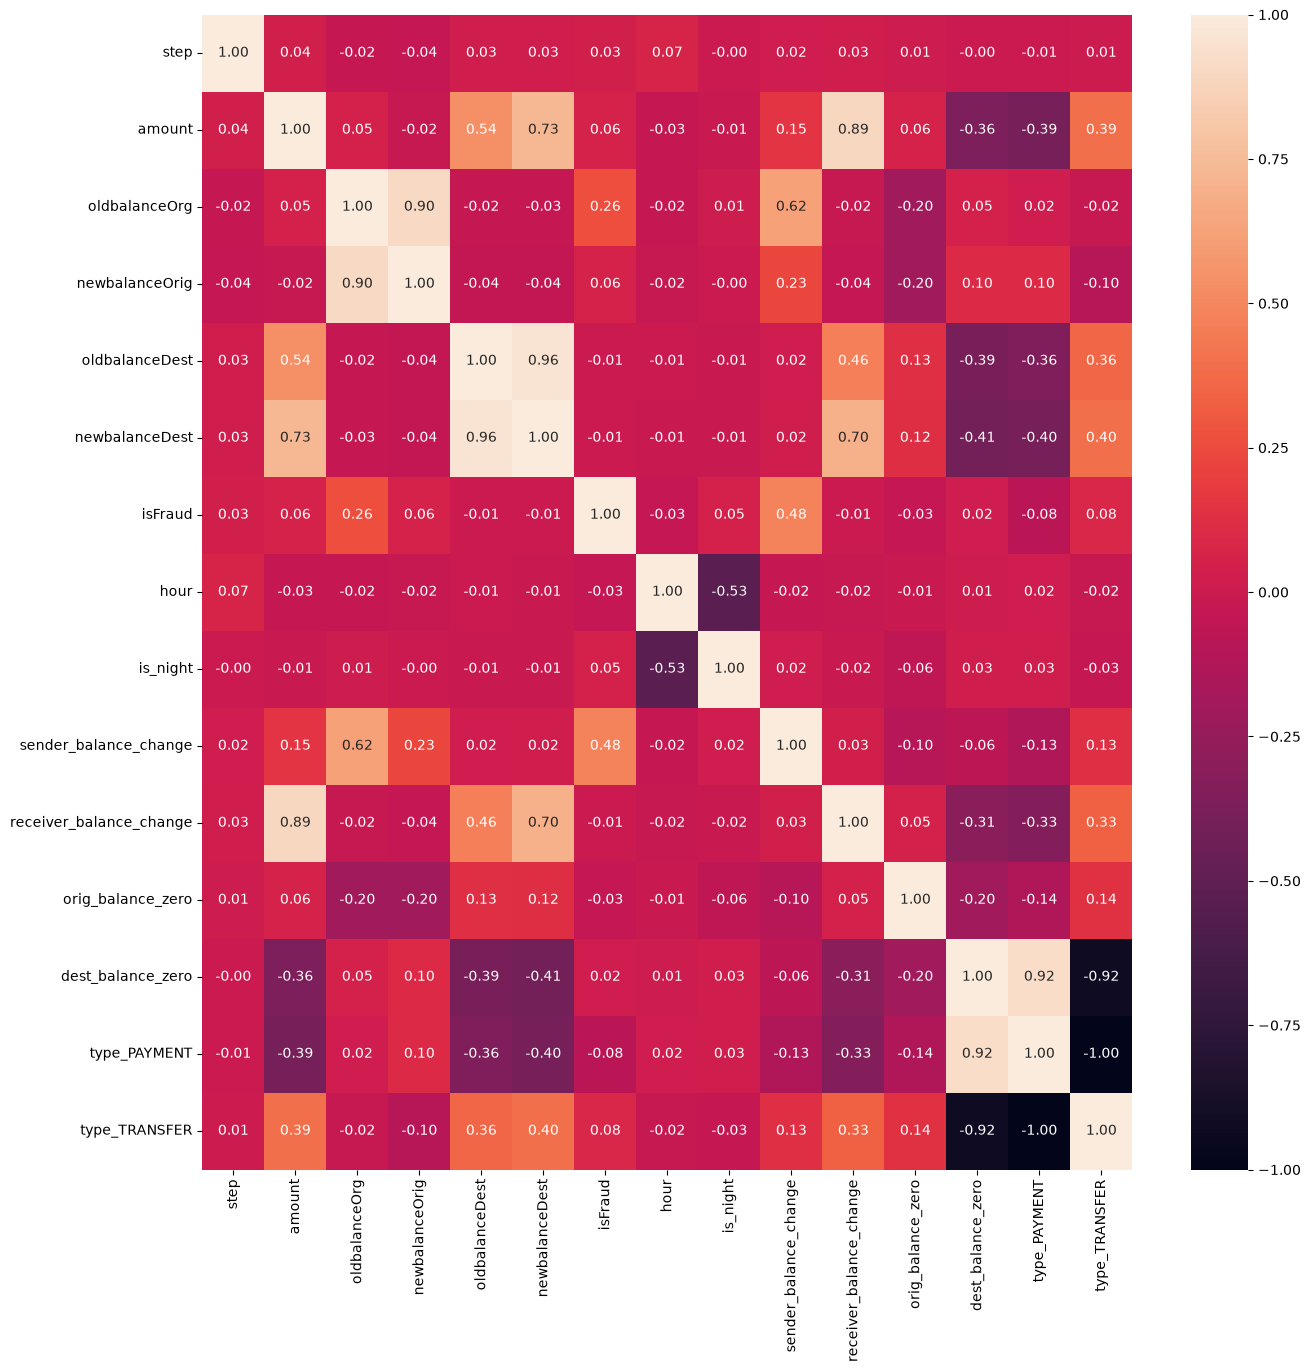

In [31]:
matrix = df.select_dtypes(np.number).corr()
plt.figure(figsize=(15,15))
sns.heatmap(matrix ,annot=True,fmt=".2f")

In [32]:
low_impact_threshold = 0.05
target_correlation = matrix["isFraud"].abs()
low_impact_cols = target_correlation[target_correlation < low_impact_threshold].sort_values().to_dict()
low_impact_cols

{'receiver_balance_change': 0.0063732497317212505,
 'oldbalanceDest': 0.0069084923757420594,
 'newbalanceDest': 0.007654365401485766,
 'dest_balance_zero': 0.017834502459665204,
 'orig_balance_zero': 0.031431264644332935,
 'hour': 0.03185445429267145,
 'step': 0.03394025750968505}

In [33]:
df.drop("type_PAYMENT",axis = 1,inplace = True)

In [34]:
df.drop("type",axis = 1,inplace = True)

In [35]:
X=df.drop('isFraud',axis=1)
y=df['isFraud']

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True,stratify=y)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [38]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,is_night,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,1,1,9839.64,0.0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,1,1,1864.28,0.0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,1,181.00,0.0,0,1,1
3,1,11668.14,41554.0,29885.86,0.0,0.0,1,1,11668.14,0.0,0,1,0
4,1,7817.71,53860.0,46042.29,0.0,0.0,1,1,7817.71,0.0,0,1,0


In [39]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=10000)

In [40]:
lr.fit(X_train_scaled,y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use 

In [41]:
y_pred1=lr.predict(X_test_scaled)
y_pred1

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [42]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred1
})
comparison.sample(20)

,actual,predicted
953563,0,0
1166469,0,0
1191090,0,0
1766394,0,0
1100382,0,0
1766192,0,0
1060700,0,0
2406362,0,0
1966006,0,0
1695019,0,0


In [43]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

acc_score=accuracy_score(y_test,y_pred1)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred1))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred1))

accuracy score :0.9996587696933844 

Confusion matrix :
[[670058     19]
 [   210    814]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670077
           1       0.98      0.79      0.88      1024

    accuracy                           1.00    671101
   macro avg       0.99      0.90      0.94    671101
weighted avg       1.00      1.00      1.00    671101



In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
dt=DecisionTreeClassifier(max_depth=5,class_weight={0: 1, 1: 10})

In [46]:
dt.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 1, 1: 10}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, 

[Text(0.5416666666666666, 0.9166666666666666, 'x[8] <= 424694.25\ngini = 0.03\nsamples = 2013303\nvalue = [2010230, 30730]'),
 Text(0.2803030303030303, 0.75, 'x[8] <= 112362.543\ngini = 0.015\nsamples = 2007580\nvalue = [2006056, 15240]'),
 Text(0.41098484848484845, 0.8333333333333333, 'True  '),
 Text(0.15151515151515152, 0.5833333333333334, 'x[0] <= 718.5\ngini = 0.007\nsamples = 1977864\nvalue = [1977149, 7150]'),
 Text(0.12121212121212122, 0.4166666666666667, 'x[8] <= 54234.85\ngini = 0.007\nsamples = 1977838\nvalue = [1977149, 6890]'),
 Text(0.06060606060606061, 0.25, 'x[12] <= 0.5\ngini = 0.004\nsamples = 1944278\nvalue = [1943855, 4230]'),
 Text(0.030303030303030304, 0.08333333333333333, 'gini = 0.0\nsamples = 1607490\nvalue = [1607490, 0]'),
 Text(0.09090909090909091, 0.08333333333333333, 'gini = 0.025\nsamples = 336788\nvalue = [336365, 4230]'),
 Text(0.18181818181818182, 0.25, 'x[5] <= 411.745\ngini = 0.137\nsamples = 33560\nvalue = [33294.0, 2660.0]'),
 Text(0.15151515151515

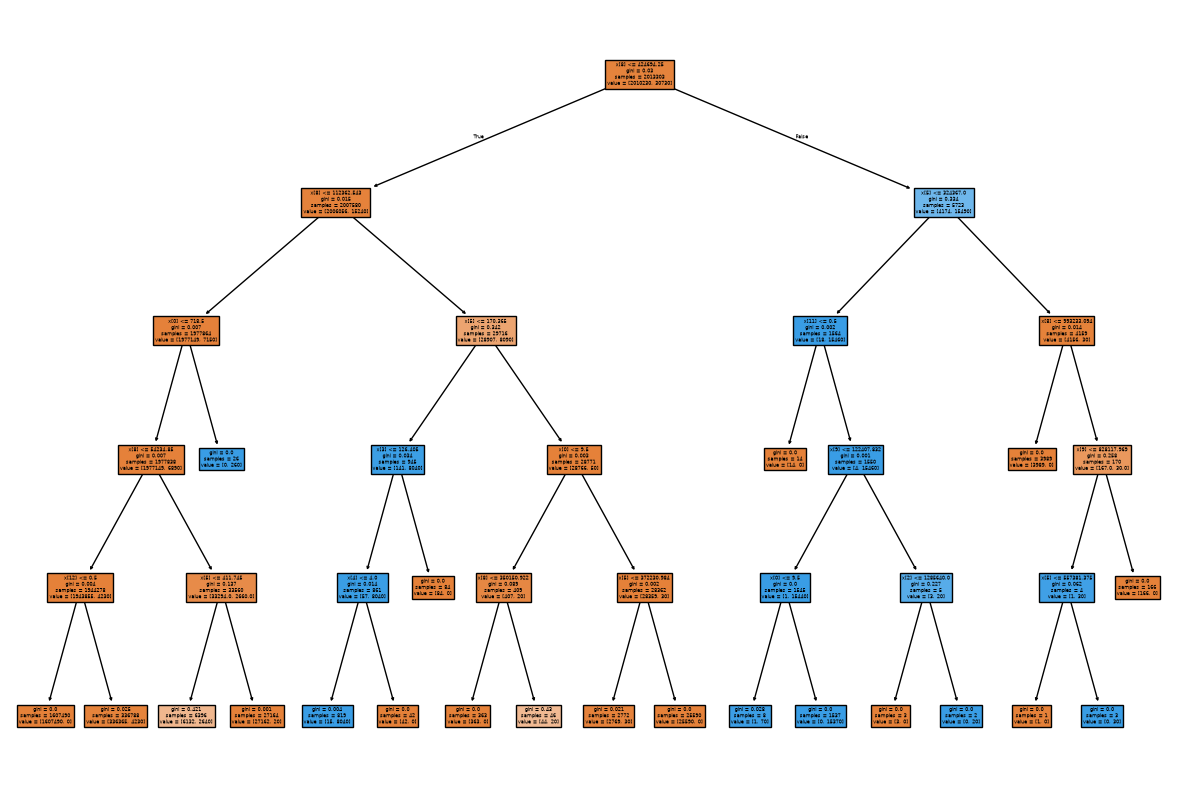

In [47]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt,filled=True)

In [48]:
dt.get_depth()

5

In [49]:
y_pred=dt.predict(X_test)

In [50]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [51]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

In [52]:
acc_score=accuracy_score(y_test,y_pred)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))

accuracy score :0.9996796309348369 

Confusion matrix :
[[670073      4]
 [   211    813]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670077
           1       1.00      0.79      0.88      1024

    accuracy                           1.00    671101
   macro avg       1.00      0.90      0.94    671101
weighted avg       1.00      1.00      1.00    671101



Trying RandomForest since DecisionTreeClassifier with accuracay 99.99% leads to overfitting since max_depth =None

In [58]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 2013303 entries, 249969 to 763804
Data columns (total 13 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   step                     int64  
 1   amount                   float64
 2   oldbalanceOrg            float64
 3   newbalanceOrig           float64
 4   oldbalanceDest           float64
 5   newbalanceDest           float64
 6   hour                     int64  
 7   is_night                 int64  
 8   sender_balance_change    float64
 9   receiver_balance_change  float64
 10  orig_balance_zero        Int64  
 11  dest_balance_zero        int64  
 12  type_TRANSFER            int64  
dtypes: Int64(1), float64(7), int64(5)
memory usage: 217.0 MB


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,class_weight={0: 1, 1: 10}, random_state=42,max_depth=10,n_jobs=-1)

In [55]:
rf_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 1, 1: 10}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max

In [56]:
y_pred = rf_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [57]:
acc_score=accuracy_score(y_test,y_pred)*100
print(f"accuracy score :{acc_score} %")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))

accuracy score :99.99850991132482 %

Confusion matrix :
[[670071      6]
 [     4   1020]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670077
           1       0.99      1.00      1.00      1024

    accuracy                           1.00    671101
   macro avg       1.00      1.00      1.00    671101
weighted avg       1.00      1.00      1.00    671101



In [59]:
import joblib 
import os

os.makedirs(r"..\models",exist_ok=True)

joblib.dump(rf_model,r"..\models\random_forest.pkl")

['..\\models\\random_forest.pkl']